In [12]:
# Загрузка библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
# from sklearn import datasets # для импорта данных
# import seaborn as sns # для визуализации статистических данных
# import matplotlib.pyplot as plt # для построения графиков

import plotly
import plotly.express as px
import seaborn as sns

unconv_data = pd.read_csv('../data/unconv.csv')
unconv_data.head()


,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


+ Well — идентификатор скважины;
+ Por — пористость скважины (%);
+ Perm — проницаемость скважины;
+ AI — акустический импеданс ($ кг/м^2*10^6 $);
+ Brittle — коэффициент хрупкости скважины (%);
+ TOC — общий органический углерод (%);
+ VR — коэффициент отражения витринита (%);
+ Prod — добыча газа в сутки (млн. кубических футов).

In [2]:
unconv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Well     200 non-null    int64  
 1   Por      200 non-null    float64
 2   Perm     200 non-null    float64
 3   AI       200 non-null    float64
 4   Brittle  200 non-null    float64
 5   TOC      200 non-null    float64
 6   VR       200 non-null    float64
 7   Prod     200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


<Axes: >

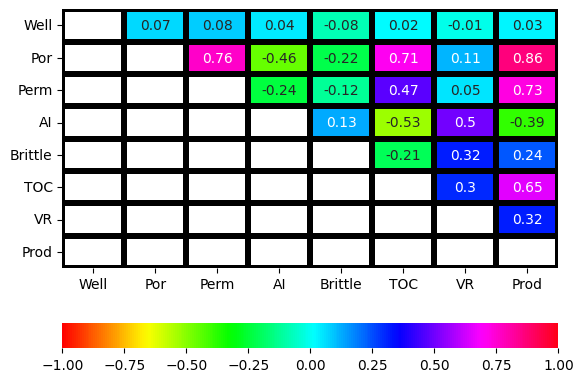

In [15]:
temp=unconv_data.corr().round(2)
#  фильтор
filtr_1=np.tril(unconv_data.corr(numeric_only=True).round(2))
filtr_2=np.triu(unconv_data.corr(numeric_only=True).round(2))

sns.heatmap(temp, # df
            annot=True, # вывод надписей (подписать фон)
            vmin=-1, vmax=1, center= 0,# граници тепловой шкалы
            cmap= 'hsv',    # палитра цветов  https://matplotlib.org/2.0.2/examples/color/colormaps_reference.html
            linewidths=3, linecolor='black', # толщина и цвет оконтовки ячеек
            cbar_kws= {'orientation': 'horizontal'},  # отображать цветовую шкалу горизонтально
            # cbar=False,  # убрать цветовую шкалу
            # square=True    # форма ячеек квадрат
            mask=filtr_1  # фильтор выводимых значений
            )# https://datastart.ru/blog/read/seaborn-heatmaps-13-sposobov-nastroit-vizualizaciyu-matricy-korrelyacii